In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
processed_path = Path("../data/processed")

# Load datasets
nav = pd.read_csv(processed_path / "clean_nav_history.csv")
fund_master = pd.read_csv(processed_path / "clean_fund_master.csv")

print("NAV Shape:", nav.shape)
print("Fund Master Shape:", fund_master.shape)

nav.head()

NAV Shape: (46000, 3)
Fund Master Shape: (40, 15)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort properly
nav = nav.sort_values(["amfi_code", "date"])

# Daily return calculation
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove first NaN return row of each fund
nav_returns = nav.dropna(subset=["daily_return"])

print(nav_returns.shape)

nav_returns.head()

(45960, 4)


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [4]:
var_results = []

for fund_code, group in nav_returns.groupby("amfi_code"):
    
    returns = group["daily_return"]

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        "amfi_code": fund_code,
        "VaR_95": round(var_95, 6),
        "CVaR_95": round(cvar_95, 6)
    })

var_df = pd.DataFrame(var_results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_df = var_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

var_df = var_df[
    ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
]

var_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [6]:
var_df = var_df.sort_values("VaR_95")

output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

var_df.to_csv(
    output_path / "var_cvar_report.csv",
    index=False
)

print("Saved successfully!")
print(var_df.head(10))

Saved successfully!
    amfi_code                                        scheme_name    VaR_95  \
22     119599          SBI Small Cap Fund - Direct Plan - Growth -0.026859   
17     119095             Axis Small Cap Fund - Regular - Growth -0.026188   
4      101207             ABSL Small Cap Fund - Regular - Growth -0.026021   
11     118634     Nippon India Small Cap Fund - Regular - Growth -0.025438   
21     119598         SBI Small Cap Fund - Regular Plan - Growth -0.024507   
39     149324              DSP Small Cap Fund - Regular - Growth -0.023483   
7      102886                UTI Mid Cap Fund - Regular - Growth -0.019220   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr... -0.019034   
25     120505           ICICI Pru Midcap Fund - Regular - Growth -0.018892   
16     119094                Axis Midcap Fund - Regular - Growth -0.018480   

     CVaR_95  
22 -0.032384  
17 -0.031667  
4  -0.032459  
11 -0.032304  
21 -0.030595  
39 -0.031036  
7  -0.023251  
2

In [7]:
# Top 5 popular funds

selected_funds = [
    100016,   # HDFC Top 100
    119551,   # SBI Bluechip
    120503,   # ICICI Bluechip
    118632,   # Nippon India Large Cap
    119092    # Axis Bluechip
]

rolling_data = nav_returns[
    nav_returns["amfi_code"].isin(selected_funds)
].copy()

print(rolling_data["amfi_code"].unique())

[100016 118632 119092 119551 120503]


In [8]:
rolling_data = rolling_data.sort_values(
    ["amfi_code", "date"]
)

rolling_data["rolling_sharpe"] = (
    rolling_data.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN


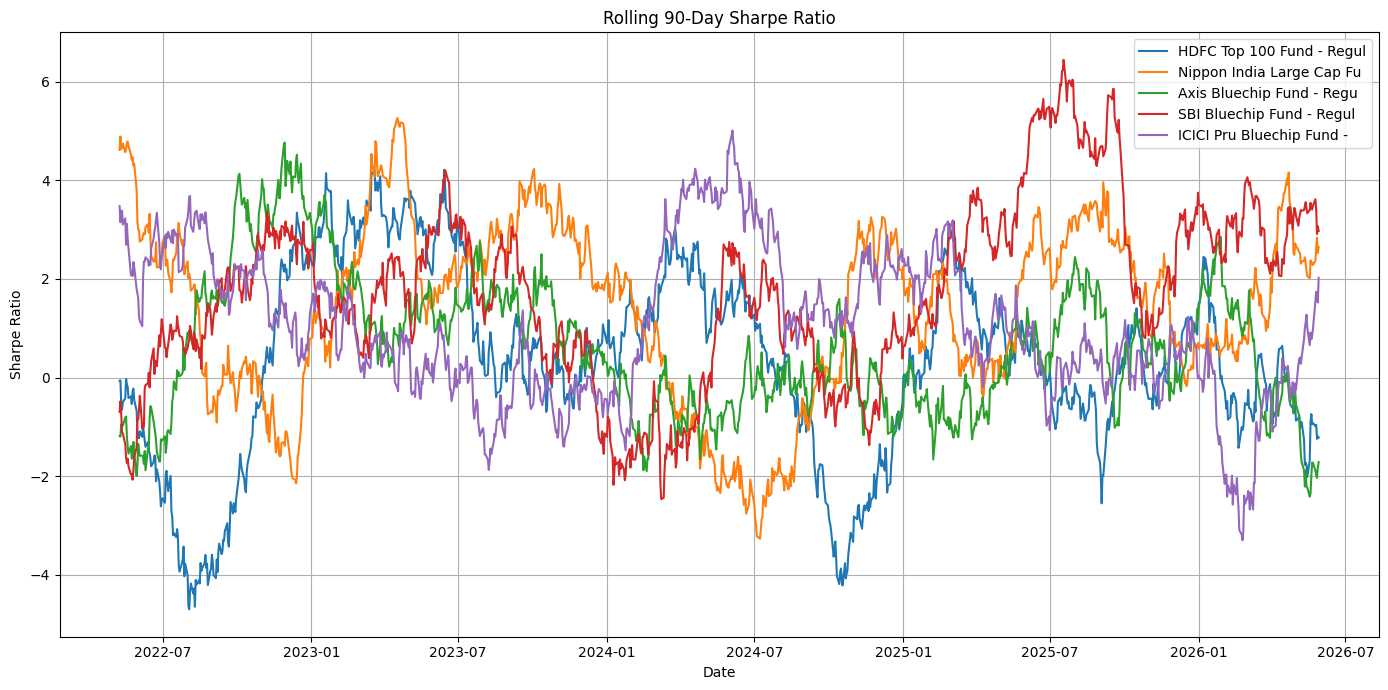

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in rolling_data["amfi_code"].unique():

    temp = rolling_data[
        rolling_data["amfi_code"] == fund
    ]

    fund_name = fund_master.loc[
        fund_master["amfi_code"] == fund,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund_name[:25]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print(transactions.shape)

transactions.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV004770,2024-01-01,102886,Lumpsum,92031,Gujarat,Surat,T30,18-25,Female,5.2,Mandate,Verified
2,INV004648,2024-01-01,118634,SIP,17860,Maharashtra,Pune,T30,36-45,Male,54.3,Mandate,Pending
3,INV002432,2024-01-01,101208,SIP,3513,Haryana,Gurugram,T30,46-55,Female,48.1,Net Banking,Verified
4,INV002338,2024-01-01,120844,Lumpsum,292991,Delhi,New Delhi,T30,26-35,Male,23.6,UPI,Verified


In [11]:
# First transaction date of each investor

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [12]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV004770,2024-01-01,102886,Lumpsum,92031,Gujarat,Surat,T30,18-25,Female,5.2,Mandate,Verified,2024
2,INV004648,2024-01-01,118634,SIP,17860,Maharashtra,Pune,T30,36-45,Male,54.3,Mandate,Pending,2024
3,INV002432,2024-01-01,101208,SIP,3513,Haryana,Gurugram,T30,46-55,Female,48.1,Net Banking,Verified,2024
4,INV002338,2024-01-01,120844,Lumpsum,292991,Delhi,New Delhi,T30,26-35,Male,23.6,UPI,Verified,2024


In [13]:
sip_only = transactions[
    transactions["transaction_type"] == "SIP"
]

avg_sip = (
    sip_only
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .round(2)
    .reset_index(name="avg_sip_amount")
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.89
1,2025,13505.21


In [14]:
total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [15]:
fund_pref = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

preferred_fund = (
    fund_pref
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

preferred_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [16]:
cohort_report = (
    avg_sip
    .merge(
        total_invested,
        on="cohort_year"
    )
    .merge(
        preferred_fund[
            ["cohort_year", "amfi_code"]
        ],
        on="cohort_year"
    )
)

cohort_report = cohort_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cohort_report.to_csv(
    "../outputs/cohort_analysis.csv",
    index=False
)

print(cohort_report)

print("\nSaved cohort_analysis.csv")

   cohort_year  avg_sip_amount  total_invested  amfi_code  \
0         2024        10996.89      3491125187     148568   
1         2025        13505.21        30455243     119599   

                                         scheme_name  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  

Saved cohort_analysis.csv


In [17]:
sip_txns = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txns = sip_txns.sort_values(
    ["investor_id", "transaction_date"]
)

print(sip_txns.shape)
sip_txns.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19592,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24413,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5615,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16847,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31914,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [18]:
sip_txns["gap_days"] = (
    sip_txns
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txns.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19592,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24413,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5615,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16847,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31914,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12614,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27650,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4814,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6463,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8240,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [20]:
sip_counts = (
    sip_txns
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

len(eligible_investors)

1362

In [21]:
continuity = (
    sip_txns[
        sip_txns["investor_id"]
        .isin(eligible_investors)
    ]
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

continuity.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [22]:
continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [23]:
continuity.to_csv(
    "../outputs/sip_continuity.csv",
    index=False
)

print(continuity["status"].value_counts())

print("\nSaved sip_continuity.csv")

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

Saved sip_continuity.csv


In [26]:
holdings = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [25]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [27]:
# Convert percentage to decimal

holdings["weight_decimal"] = holdings["weight_pct"] / 100

# HHI calculation per fund

sector_hhi = (
    holdings
    .groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [28]:
sector_hhi = sector_hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi = sector_hhi[
    [
        "amfi_code",
        "scheme_name",
        "HHI"
    ]
]

sector_hhi.head()

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.139534
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.129332
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709


In [29]:
sector_hhi = sector_hhi.sort_values(
    "HHI",
    ascending=False
)

sector_hhi.to_csv(
    "../outputs/sector_hhi.csv",
    index=False
)

print("Saved sector_hhi.csv")

sector_hhi.head(10)

Saved sector_hhi.csv


,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
23,120841,Kotak Bluechip Fund - Regular - Growth,0.149680


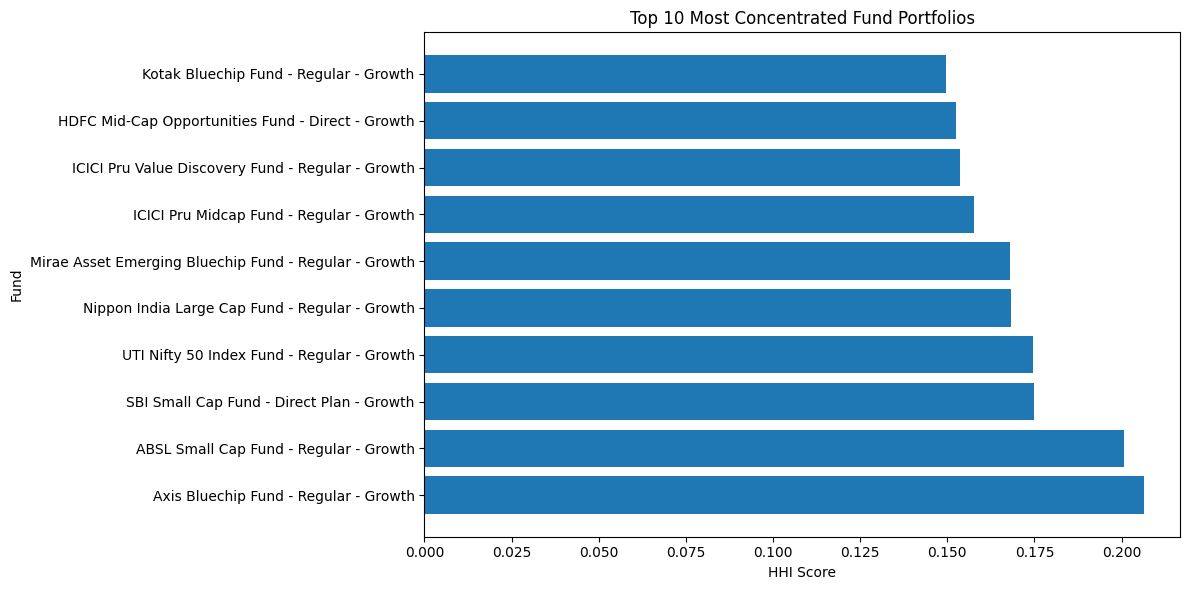

In [30]:
import matplotlib.pyplot as plt

top10 = sector_hhi.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["HHI"]
)

plt.xlabel("HHI Score")
plt.ylabel("Fund")
plt.title("Top 10 Most Concentrated Fund Portfolios")

plt.tight_layout()

plt.savefig(
    "../outputs/sector_hhi_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Advanced Analytics Findings

## 1. Value at Risk (VaR)
Small-cap funds exhibited the highest downside risk, with VaR values exceeding -2.5%.

## 2. Conditional VaR (CVaR)
Small-cap schemes experienced the deepest tail losses during adverse market conditions.

## 3. Rolling Sharpe Ratio
Large-cap funds showed more stable risk-adjusted performance compared to small-cap funds.

## 4. Investor Cohorts
2025 investors contributed higher average SIP amounts, while 2024 cohorts contributed larger overall capital.

## 5. SIP Continuity
A large number of investors were identified as at-risk due to SIP gaps greater than 35 days.

## 6. Fund Recommendation Engine
The recommendation model successfully ranked funds using Sharpe Ratio and risk category.

## 7. Sector Concentration Risk
Several equity funds showed significantly higher HHI values, indicating concentrated sector exposure.